# 04 · Demo: predictions, Grad-CAM and the sample gallery

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atilimai/plant-ai-project/blob/main/notebooks/04_demo_plan.ipynb)

Issues #09 and #14. Loads an exported model (local `models/exported/` or the Hugging Face Hub),
classifies a few held-out images, explains them with Grad-CAM and shows the confidence-stratified gallery.

In [1]:
# Setup: on Colab clone the repo and install deps; locally just move to the repo root.
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not Path("plant-ai-project").exists():
        !git clone -q https://github.com/atilimai/plant-ai-project.git
    %cd plant-ai-project
    !pip install -q -r requirements.txt
else:
    while not Path("configs/data.yaml").exists() and Path.cwd() != Path.cwd().parent:
        os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
print("repo root:", Path.cwd().name)

repo root: plant-ai-project


In [2]:
import io

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as IPyImage, display
from PIL import Image

from src.data.labels import pretty_name
from src.inference.predictor import Predictor

%config InlineBackend.figure_formats = ["jpeg"]


def show(path, width=900):
    """Embed a saved figure as a downscaled JPEG so the notebook stays small."""
    img = Image.open(path).convert("RGB")
    img.thumbnail((width * 2, width * 4))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    display(IPyImage(data=buf.getvalue(), format="jpeg", width=width))


RUN = "multiclass_mobilenet_v2"
local = Path("models/exported") / RUN
if local.exists():
    model_dir = local
else:
    from huggingface_hub import snapshot_download
    model_dir = Path(snapshot_download("atilimai/plantvillage-leaf-disease-classifier", allow_patterns=[f"{RUN}/*"])) / RUN
predictor = Predictor.load(model_dir)
print(predictor.meta["arch"], "·", len(predictor.class_names), "classes")

mobilenet_v2 · 38 classes


## Classify held-out images

Images come from the test split, so the model has never seen these leaves.

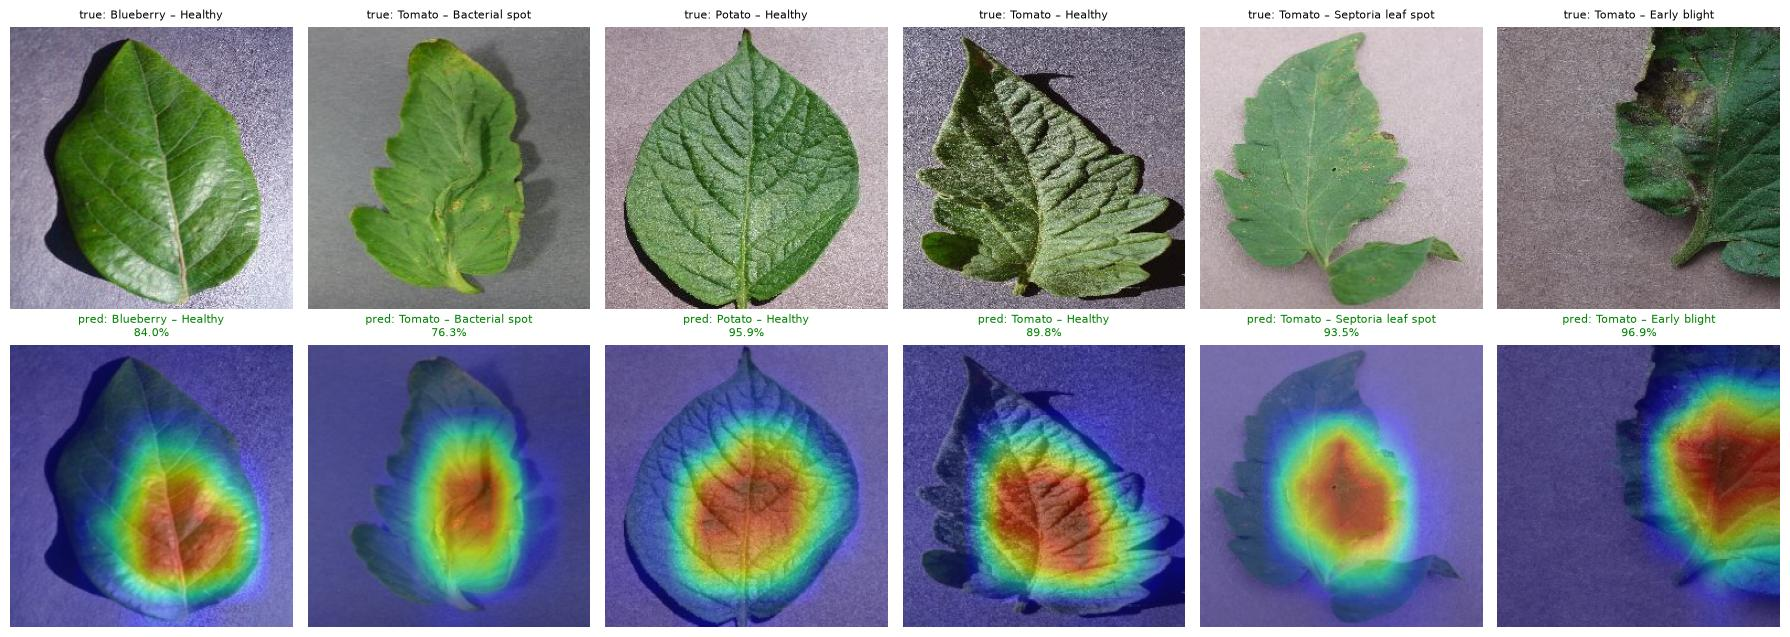

In [3]:
IMAGE_ROOT = Path("data/raw/plantvillage")
test = pd.read_csv("data/splits/manifest.csv").query("split == 'test'")
picks = test.groupby("class_name").sample(1, random_state=3).sample(6, random_state=3)

fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for i, (_, row) in enumerate(picks.iterrows()):
    image = Image.open(IMAGE_ROOT / row["path"]).convert("RGB")
    pred, cam, blended = predictor.explain(image)
    ok = pred.label == row["class_name"]
    axes[0, i].imshow(image)
    axes[0, i].set_title(f"true: {pretty_name(row['class_name'])}", fontsize=8)
    axes[1, i].imshow(blended)
    axes[1, i].set_title(f"pred: {pred.display_name}\n{pred.confidence:.1%}", fontsize=8,
                         color="green" if ok else "red")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()

## Your own image

On Colab, upload a photo of a single leaf on a plain background. Field photos are out of distribution; expect unreliable answers.

In [4]:
if IN_COLAB:
    from google.colab import files
    for name in files.upload():
        pred, _, blended = predictor.explain(Image.open(name))
        plt.imshow(blended); plt.axis("off")
        plt.title(f"{pred.display_name} ({pred.confidence:.1%})")
        plt.show()
        print(pred.top_k)

## Sample predictions gallery (issue #09)

Confidence-stratified: confident hits, borderline hits and the most confident errors.

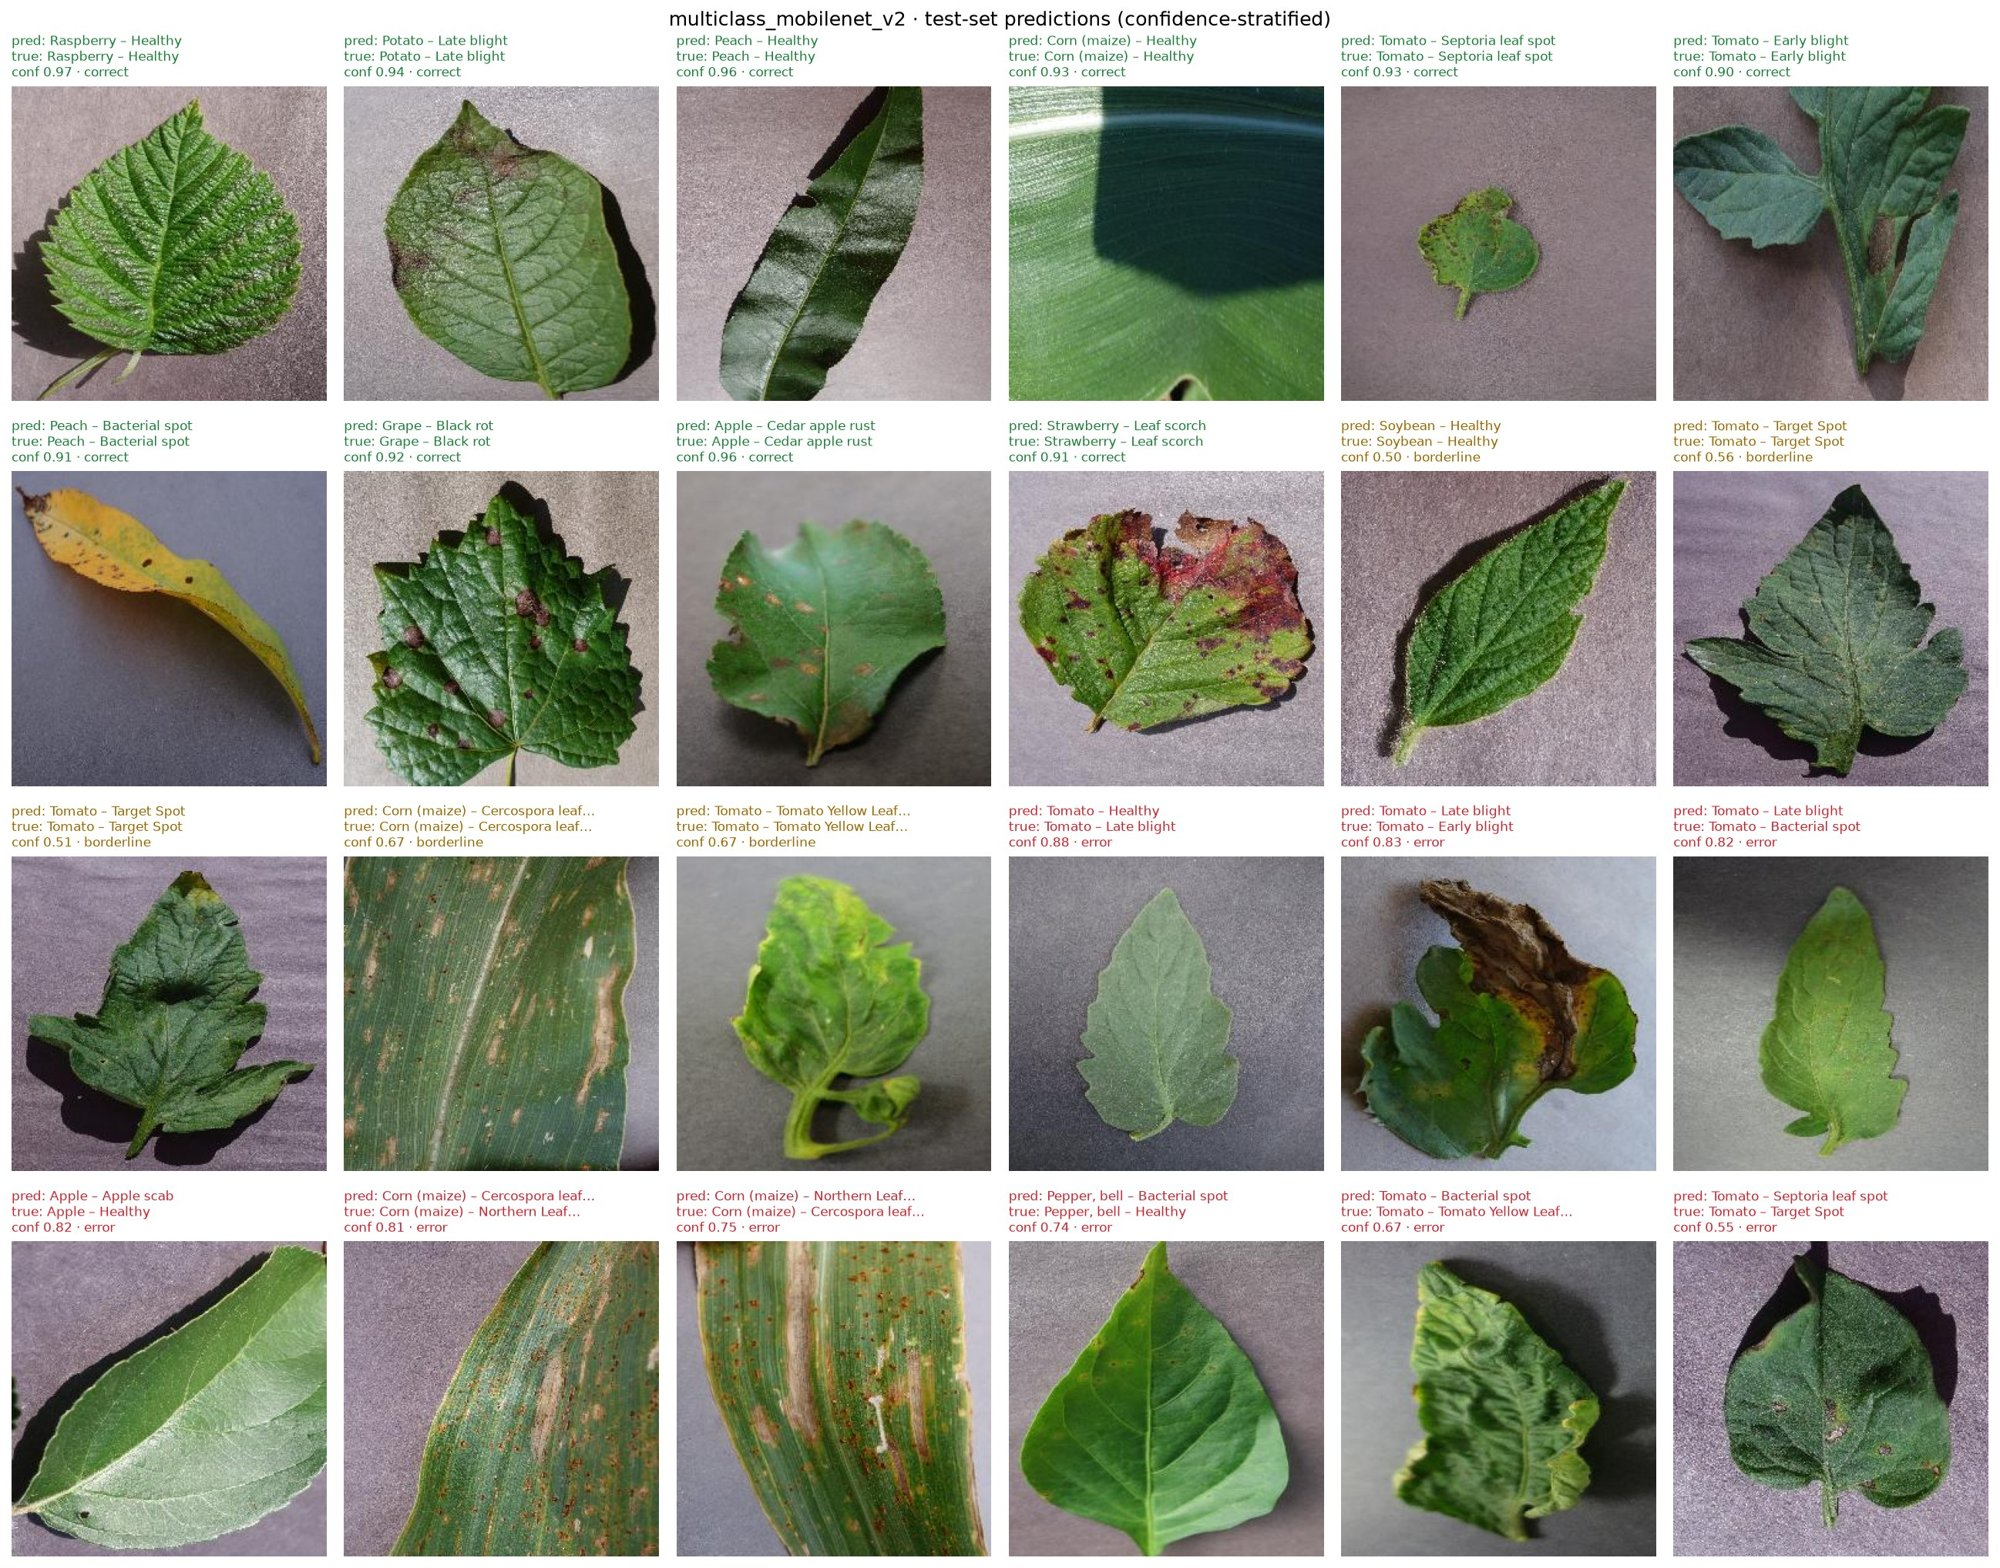

In [5]:
show(f"artifacts/sample_outputs/{RUN}/prediction_gallery.jpg", width=1000)

## Interactive demo

`python app/app.py` starts the Gradio app locally; the same app is packaged as a Hugging Face Space by `scripts/build_hf_release.py`.